### Car Price Prediction

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor , AdaBoostRegressor , HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import root_mean_squared_error , r2_score , mean_absolute_error
from sklearn.model_selection import train_test_split , cross_validate , cross_val_score , GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer


In [117]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
import warnings

In [2]:
warnings.filterwarnings('ignore')

#!pip install opendatsets --upgrade

In [3]:
#!python.exe -m pip install --upgrade pip

In [4]:
#!pip install legacy-cgi

In [5]:
'''import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/zafarali27/car-price-prediction"
)'''

'import opendatasets as od\n\nod.download(\n    "https://www.kaggle.com/datasets/zafarali27/car-price-prediction"\n)'

In [6]:
df = pd.read_csv("car-price-prediction/car_price_prediction_.csv")
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


In [7]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [9]:
df.describe(include = 'object')

,Brand,Fuel Type,Transmission,Condition,Model
count,2500,2500,2500,2500,2500
unique,7,4,2,3,28
top,Toyota,Diesel,Manual,Used,Fiesta
freq,374,655,1308,855,103


In [119]:
df.columns.tolist()

['Car ID',
 'Brand',
 'Year',
 'Engine Size',
 'Fuel Type',
 'Transmission',
 'Mileage',
 'Condition',
 'Price',
 'Model']

In [10]:
cat_cols = df.select_dtypes(include = 'object').columns.tolist()
num_cols = df.select_dtypes(include = np.number).columns.tolist()
for col in cat_cols:
    print(f"-----------{col}---------------")
    print(df[col].unique())
    print()

-----------Brand---------------
['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']

-----------Fuel Type---------------
['Petrol' 'Electric' 'Diesel' 'Hybrid']

-----------Transmission---------------
['Manual' 'Automatic']

-----------Condition---------------
['New' 'Used' 'Like New']

-----------Model---------------
['Model X' '5 Series' 'A4' 'Model Y' 'Mustang' 'Q7' 'Q5' 'Civic'
 'Explorer' 'Model 3' 'Fiesta' 'X3' 'GLA' 'A3' 'X5' 'C-Class' 'E-Class'
 'CR-V' 'Camry' 'Accord' 'GLC' 'Corolla' 'Fit' 'Model S' 'Prius'
 '3 Series' 'RAV4' 'Focus']



In [24]:
df.isna().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

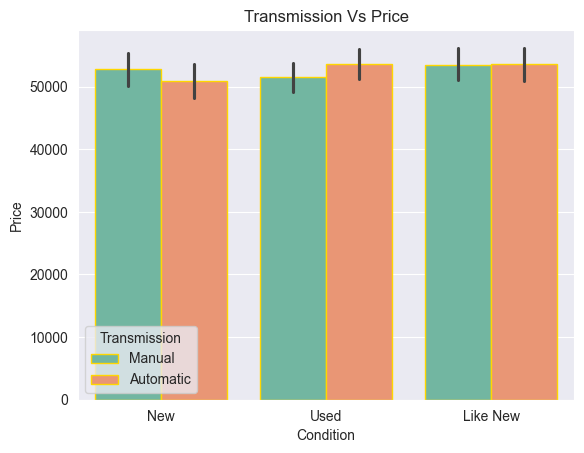

In [85]:
sns.barplot(x = 'Condition' , y = 'Price' , hue = 'Transmission' ,linewidth = 1 , edgecolor = 'gold',data = df , palette = 'Set2')
plt.title("Transmission Vs Price")
plt.show()

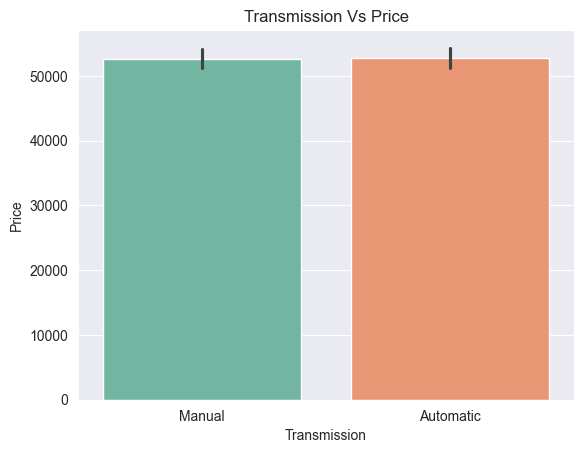

In [80]:
sns.barplot(x = 'Transmission' , y = 'Price' , hue = 'Transmission' ,data = df , palette = 'Set2')
plt.title("Transmission Vs Price")
plt.show()

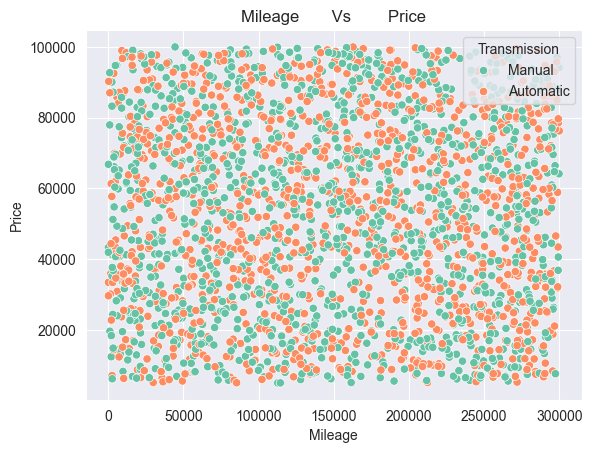

In [88]:
sns.scatterplot(x = 'Mileage' , y = 'Price', hue = 'Transmission' , data = df , palette = 'Set2')
plt.title('Mileage       Vs        Price')
plt.show()

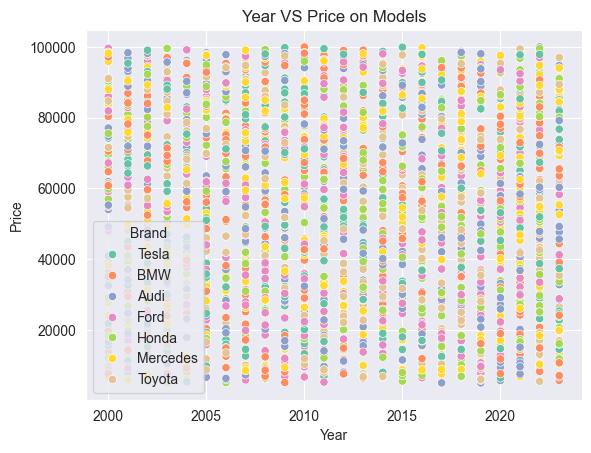

In [78]:
sns.scatterplot(x= 'Year' , y = 'Price' , hue = 'Brand' , data = df , palette ='Set2')
plt.title("Year VS Price on Models")
plt.show()

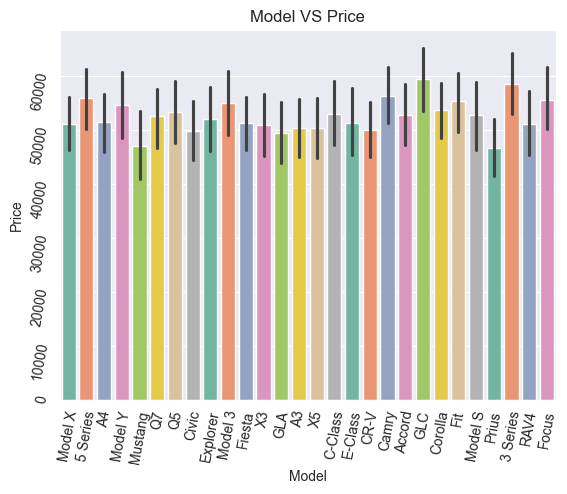

In [68]:
sns.barplot(x = 'Model' , y = "Price" ,hue = 'Model' , data = df, palette = 'Set2')
plt.xticks(rotation = 80)
plt.yticks(rotation = 80)
plt.title("Model VS Price")
plt.show()

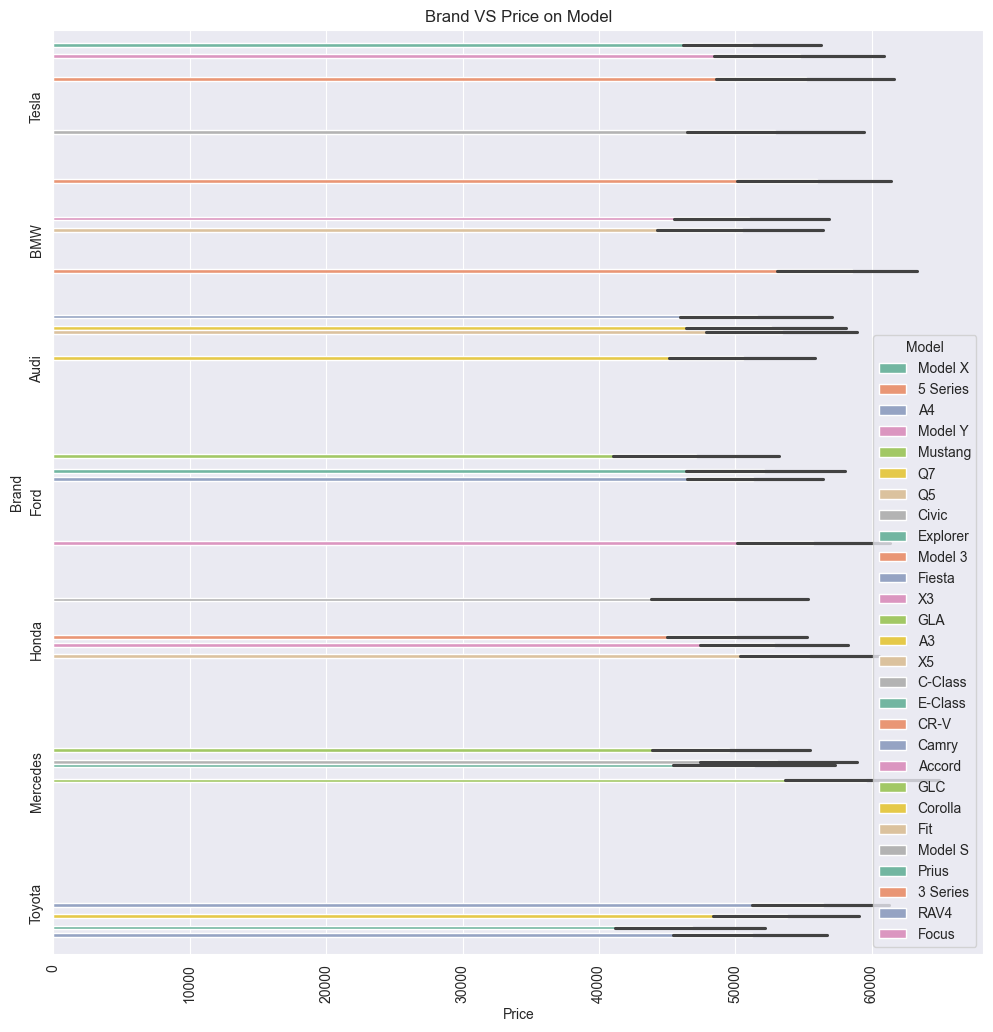

In [74]:
plt.figure(figsize = (12,12))
sns.barplot(x = "Price" , y = "Brand" , hue = "Model" ,data = df, palette = 'Set2')
plt.title('Brand VS Price on Model')
plt.xticks(rotation = 90)
plt.yticks(rotation = 90)
plt.show()


In [11]:
sns.set_style("darkgrid")

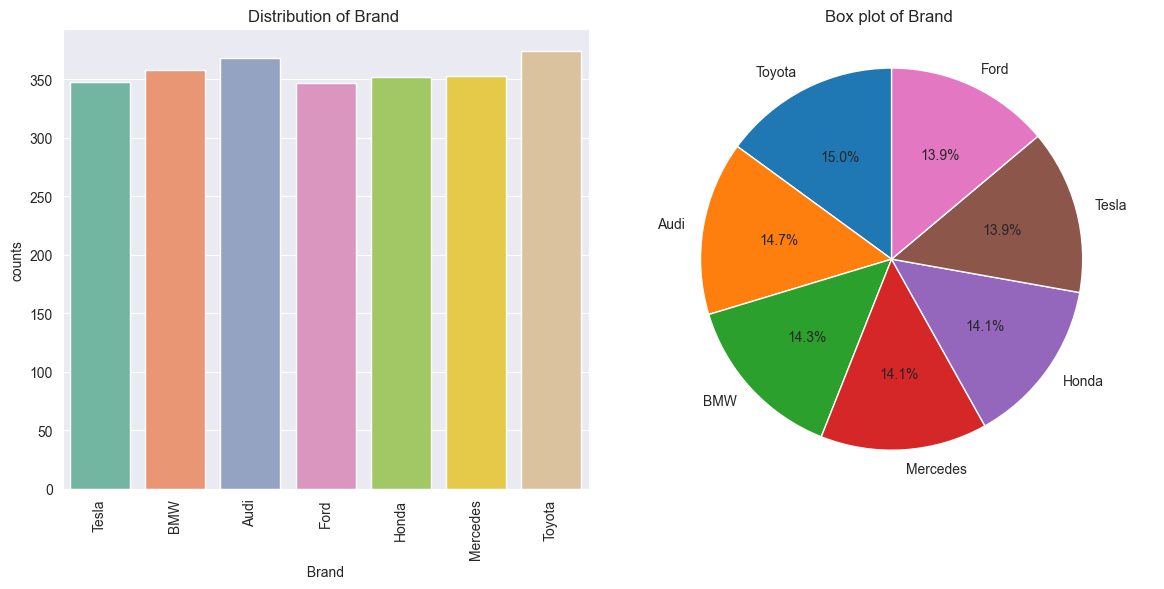

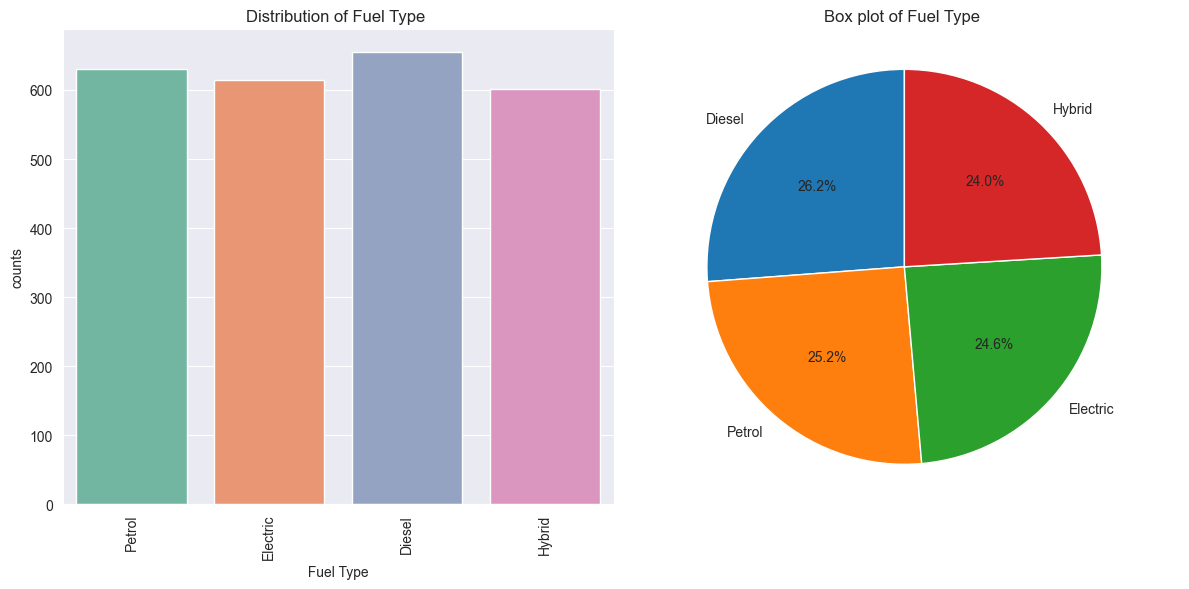

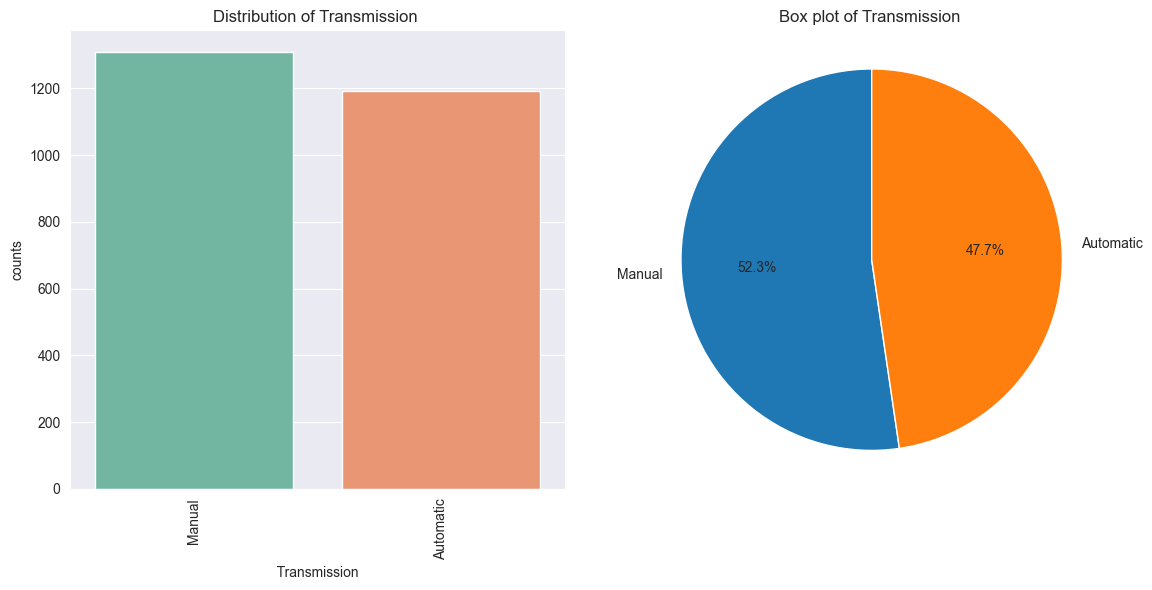

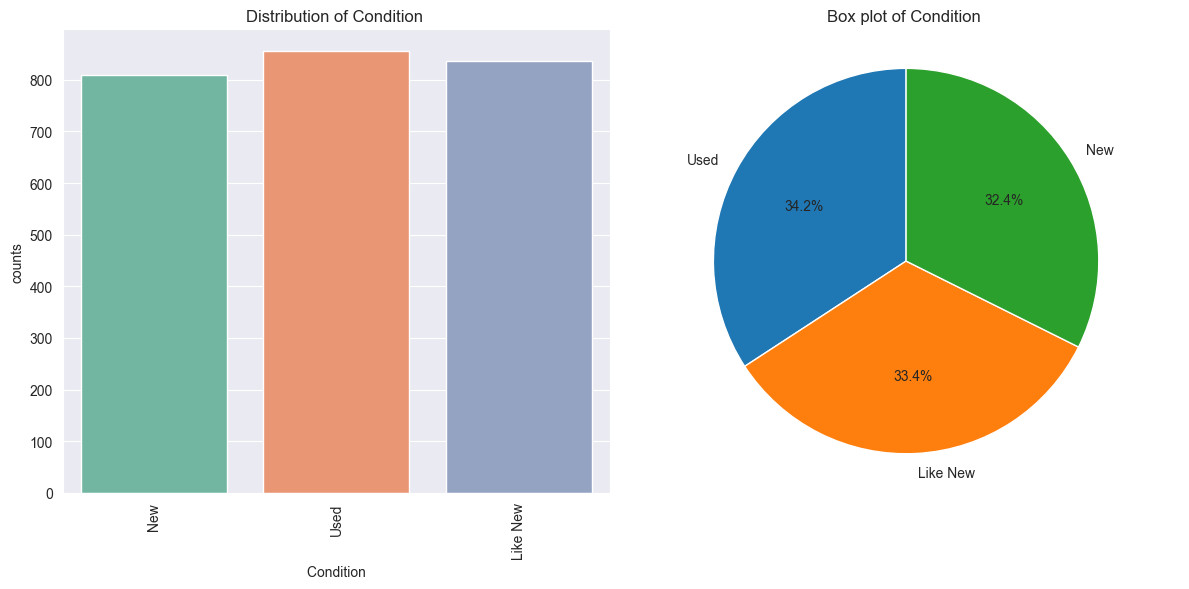

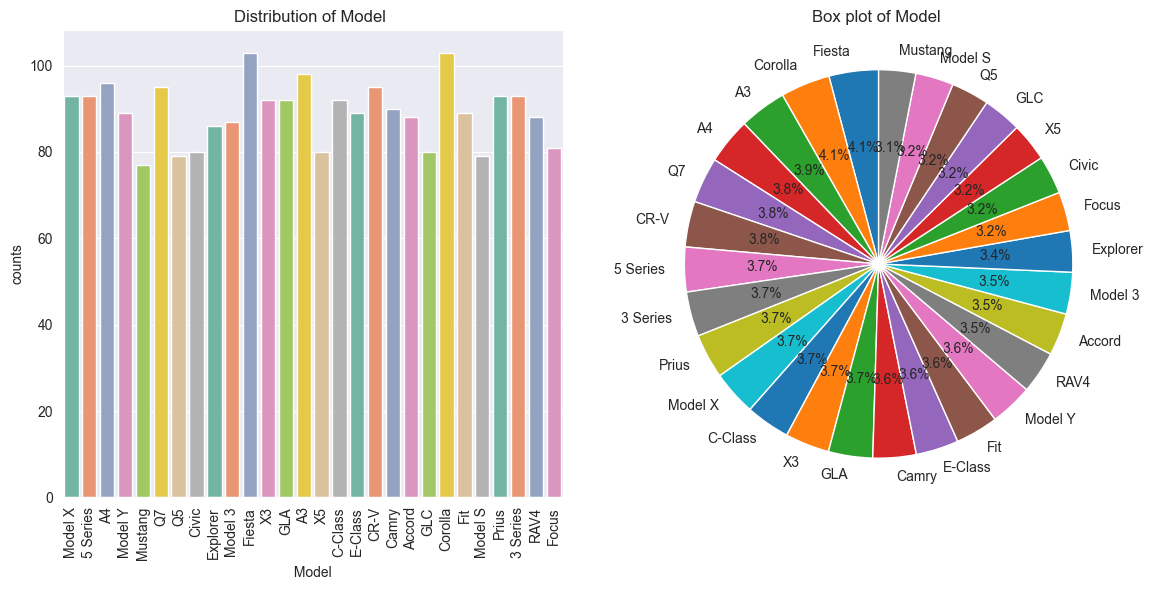

In [12]:
for col in cat_cols:
    counts = df[col].value_counts()
    plt.figure(figsize = (12,6))
    plt.subplot(1,2,1)
    sns.countplot(x = df[col], hue = df[col] ,palette = 'Set2' , legend = False)
    plt.title(f"Distribution of {col} ")
    plt.xlabel(f" {col} ")
    plt.ylabel("counts")
    plt.xticks(rotation = 90)


    plt.subplot(1,2,2)
    plt.pie(counts , labels = counts.index , autopct = "%1.1f%%" , startangle = 90)
    plt.title(f"Box plot of {col} ")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    print("\n")

C:\Users\tanu\AppData\Local\Temp\ipykernel_20404\2333313589.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col] ,  palette = 'Set2')


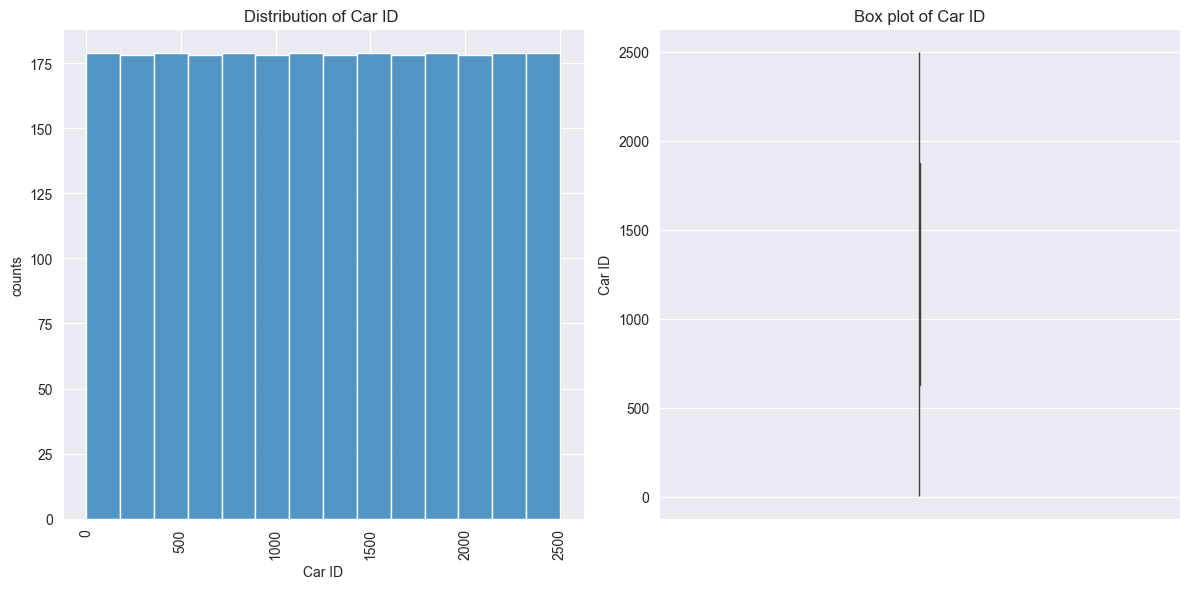

C:\Users\tanu\AppData\Local\Temp\ipykernel_20404\2333313589.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col] ,  palette = 'Set2')


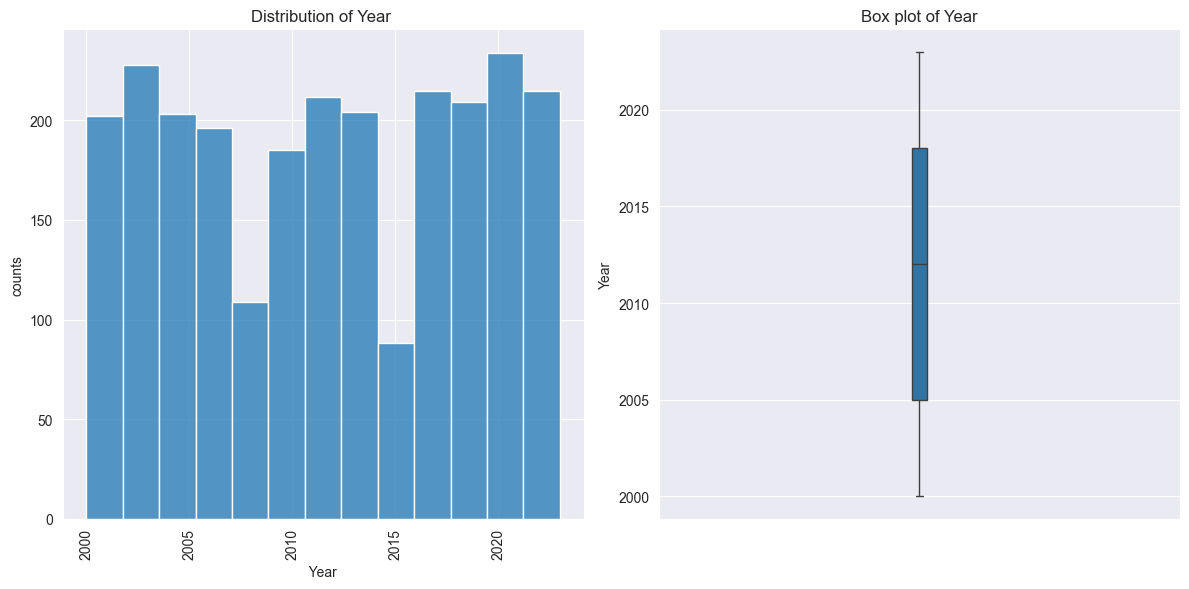

C:\Users\tanu\AppData\Local\Temp\ipykernel_20404\2333313589.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col] ,  palette = 'Set2')


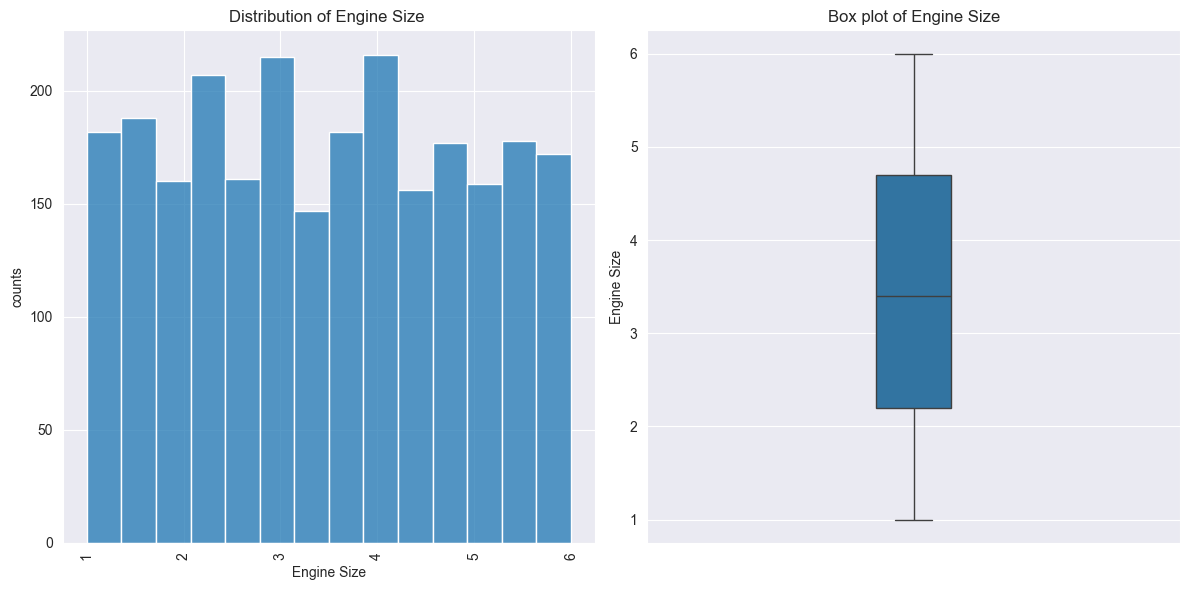

C:\Users\tanu\AppData\Local\Temp\ipykernel_20404\2333313589.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col] ,  palette = 'Set2')


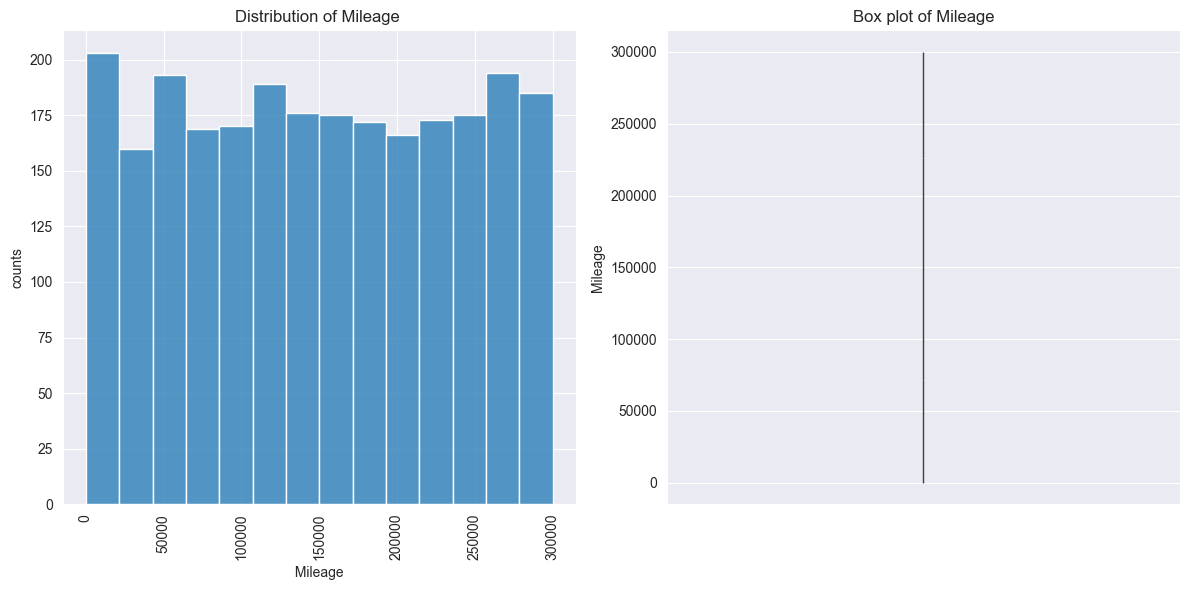

C:\Users\tanu\AppData\Local\Temp\ipykernel_20404\2333313589.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col] ,  palette = 'Set2')


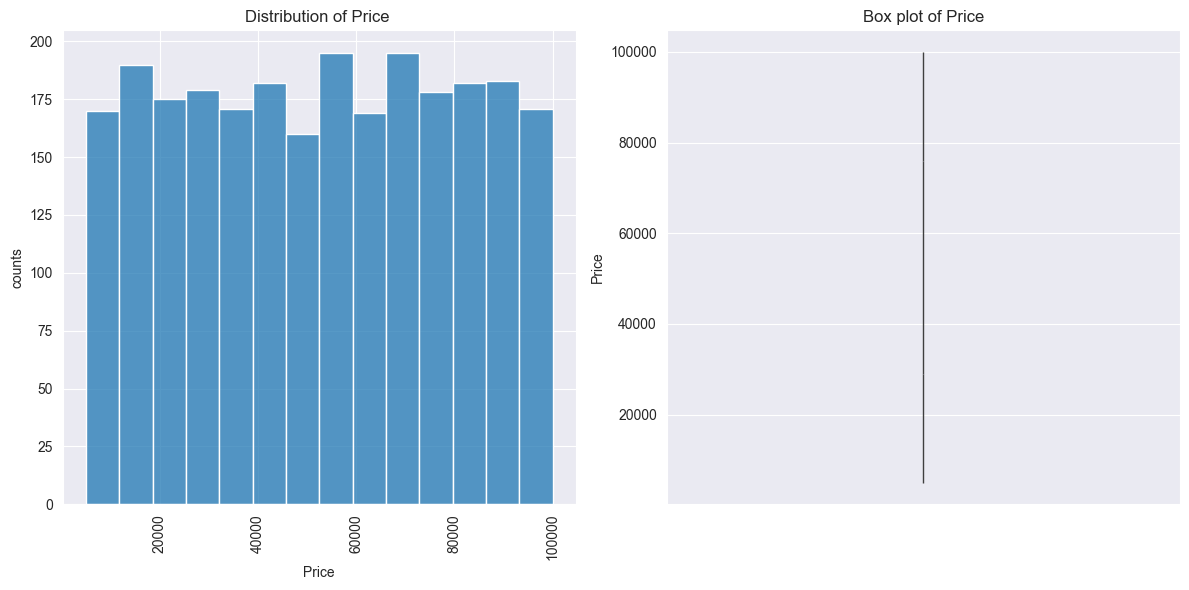

In [13]:
for col in num_cols:
    
    plt.figure(figsize = (12,6))
    plt.subplot(1,2,1)
    sns.histplot(x = df[col] ,  palette = 'Set2')
    plt.title(f"Distribution of {col} ")
    plt.xlabel(f" {col} ")
    plt.ylabel("counts")
    plt.xticks(rotation = 90)


    plt.subplot(1,2,2)
    sns.boxplot(df[col])
    plt.title(f"Box plot of {col}")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    print("\n")

<Axes: xlabel='Brand'>

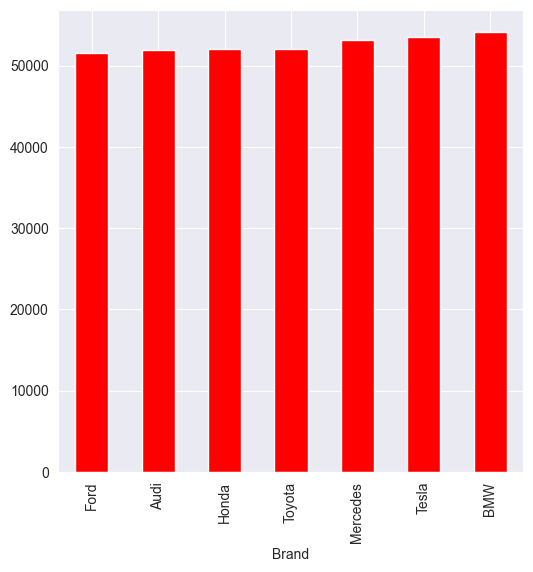

In [14]:
df.groupby("Brand")['Price'].mean().sort_values().plot(kind = 'bar' , figsize = (6,6) , color = 'red' )

<Axes: xlabel='Brand', ylabel='Price'>

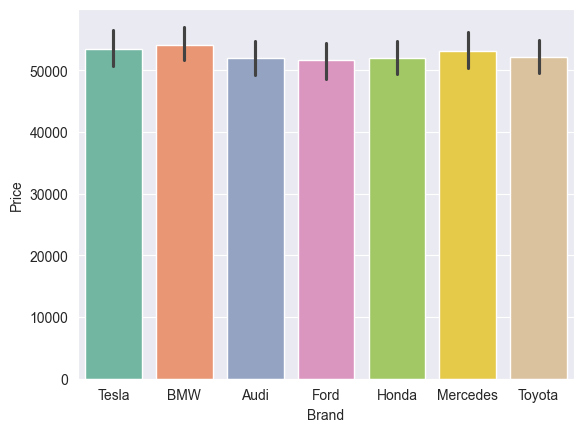

In [15]:
sns.barplot(x = 'Brand' , y = 'Price' , palette = "Set2" , hue = 'Brand' ,data = df)

<Axes: xlabel='Brand'>

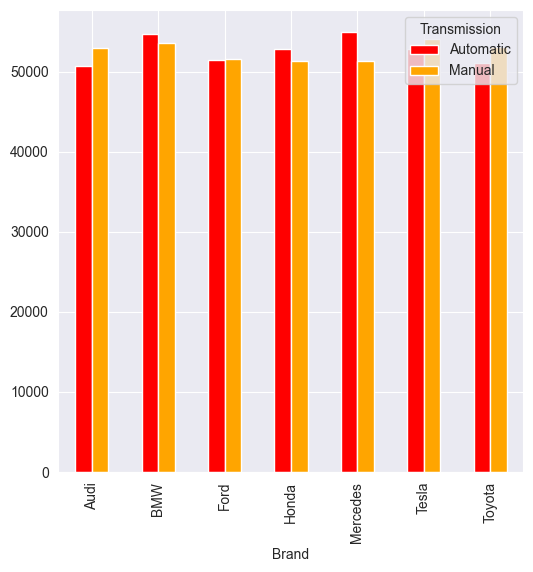

In [16]:
df.groupby(["Transmission" ,
            'Brand'])["Price"].mean().sort_values(ascending = False).reset_index().pivot(index= 'Brand' ,
                                                                                                         columns = 'Transmission' , 
                                                                                                         values = 'Price').plot(kind = 'bar', 
                                                                                                                                figsize = (6,6), 
                                                                                                                                color = ['red', "orange"])

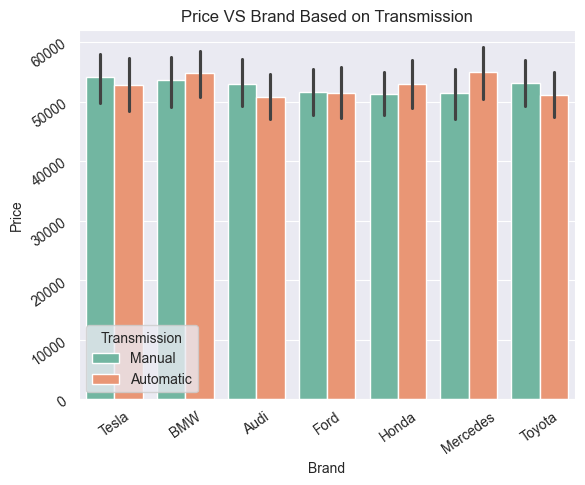

In [17]:
sns.barplot(x = "Brand" , y = "Price" , hue = "Transmission" , data = df , palette = "Set2")
plt.title("Price VS Brand Based on Transmission")
plt.legend(title = 'Transmission')
plt.xticks(rotation = 35)
plt.yticks(rotation  = 35)
plt.show()

<Axes: xlabel='Brand'>

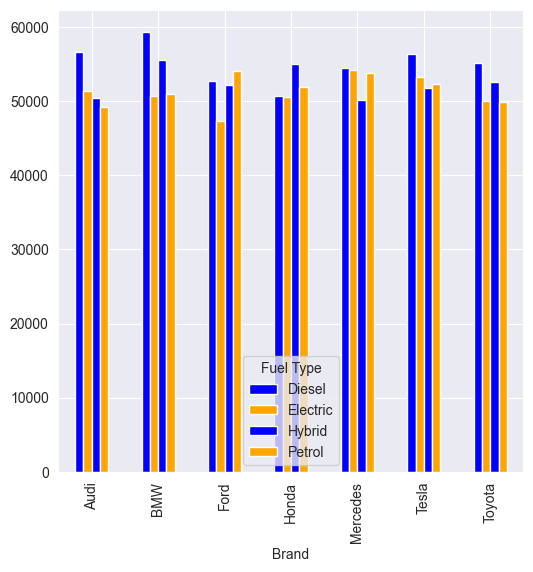

In [18]:
df.groupby(["Fuel Type" ,
            'Brand'])["Price"].mean().sort_values(ascending = False).reset_index().pivot(index= 'Brand' ,
                                                                                                         columns = 'Fuel Type' , 
                                                                                                         values = 'Price').plot(kind = 'bar', 
                                                                                                                                figsize = (6,6), 
                                                                                                                                color = ['blue', "orange"])

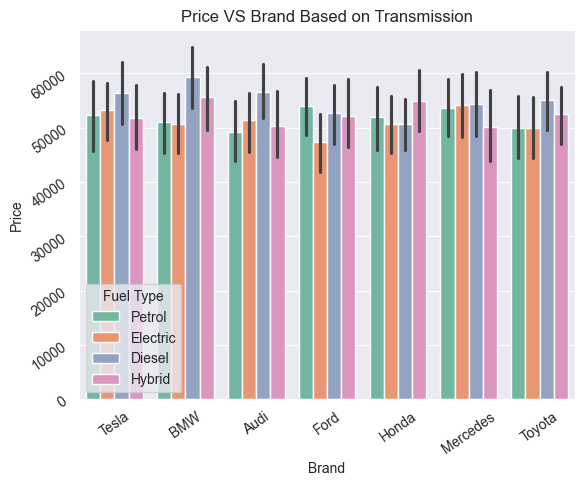

In [19]:
sns.barplot(x = "Brand" , y = "Price" , hue = "Fuel Type" , data = df , palette = "Set2")
plt.title("Price VS Brand Based on Transmission")
plt.legend(title = 'Fuel Type')
plt.xticks(rotation = 35)
plt.yticks(rotation  = 35)
plt.show()

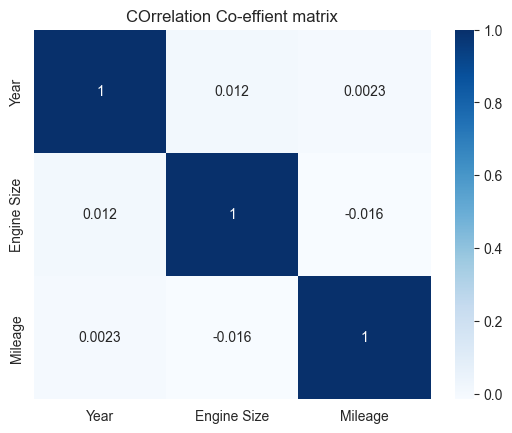

In [92]:
sns.heatmap(df[numeric_cols].corr(), cmap = 'Blues' , annot = True)
plt.title("COrrelation Co-effient matrix")
plt.show()

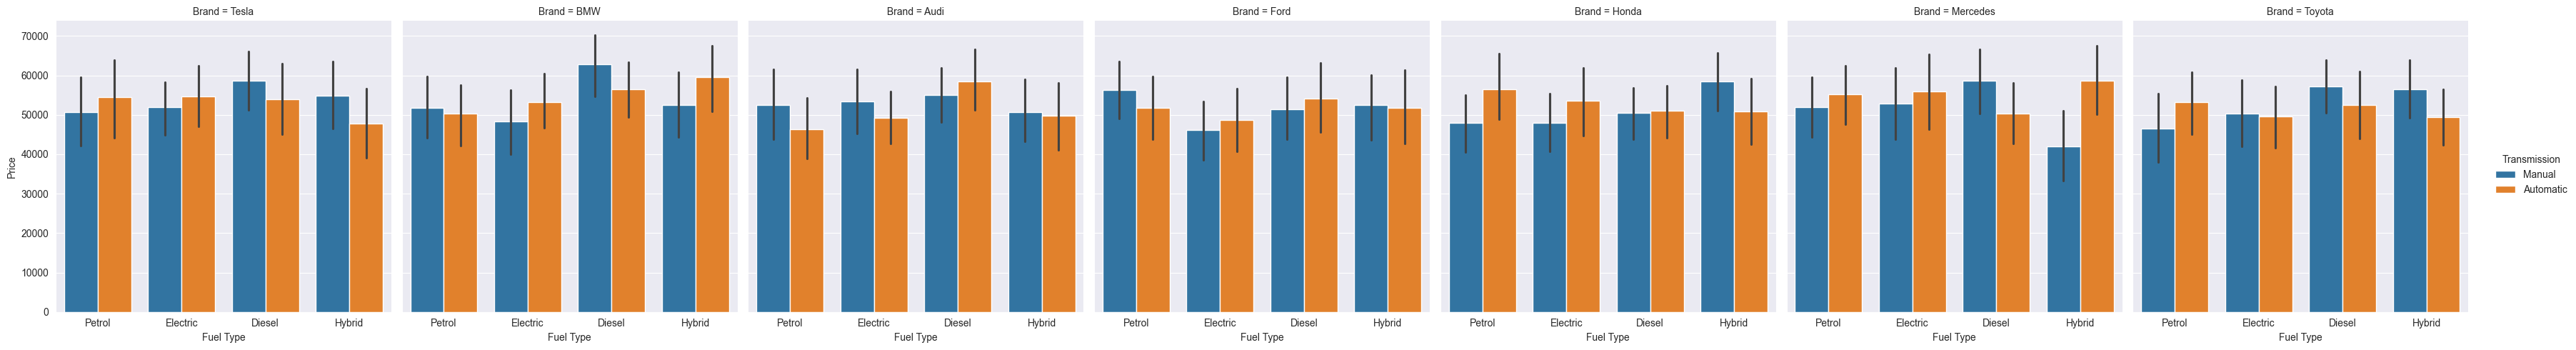

In [93]:
sns.catplot(data = df , x = 'Fuel Type' , y = 'Price' , col = 'Brand' , hue = "Transmission" , kind = 'bar')

KeyboardInterrupt: 

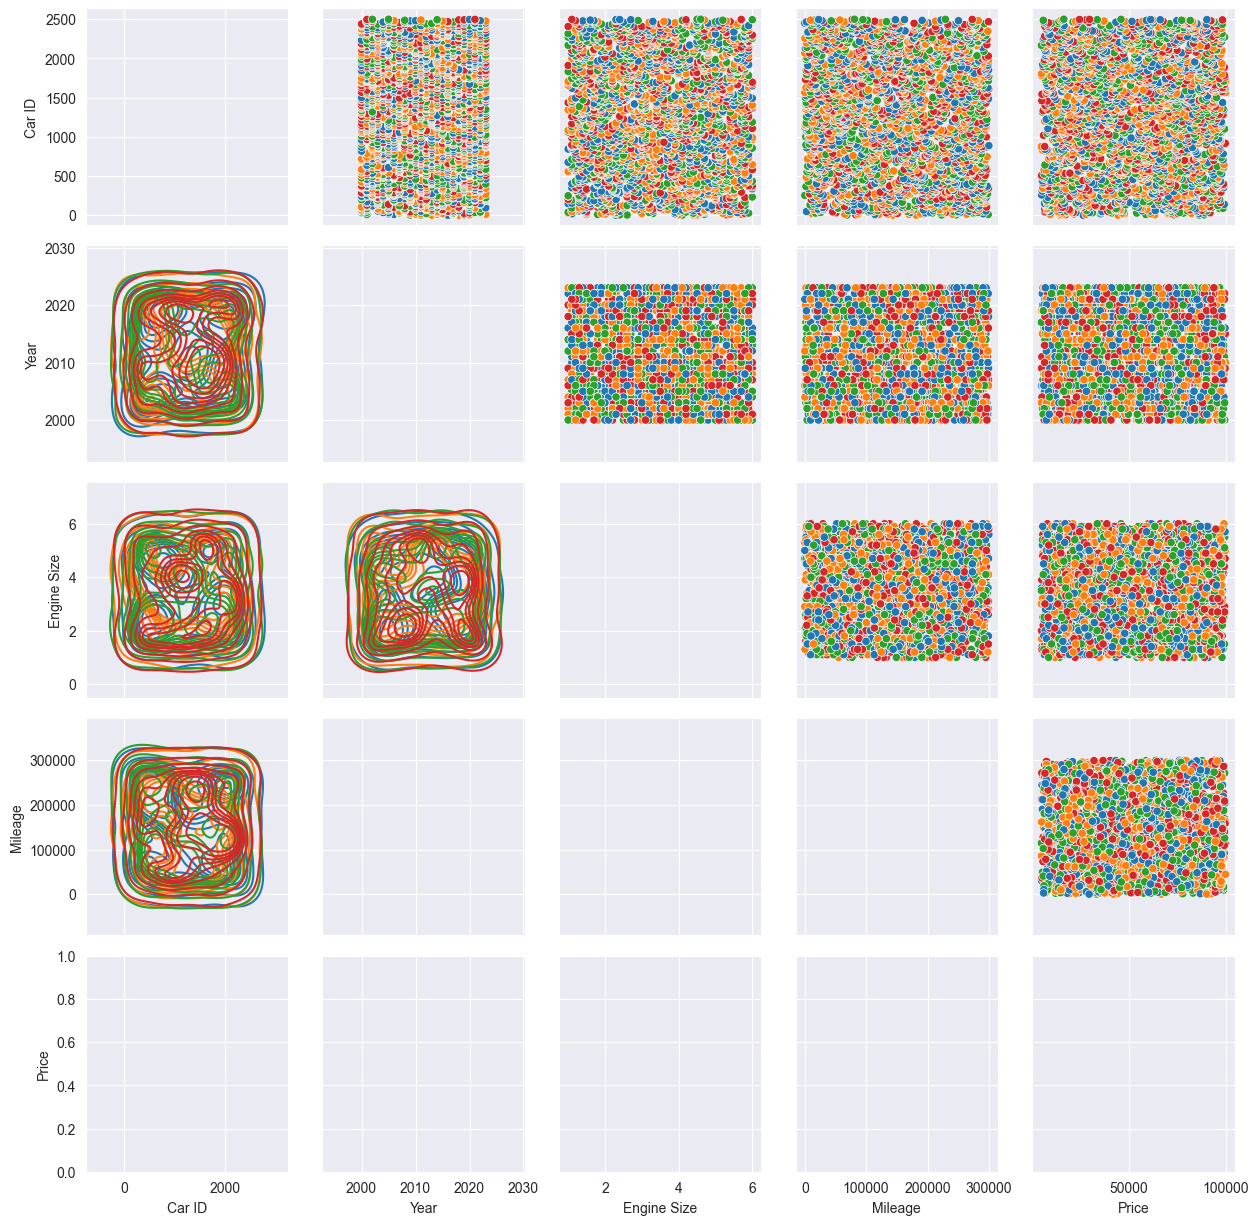

In [94]:
g = sns.PairGrid(df , hue = 'Fuel Type')

g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)

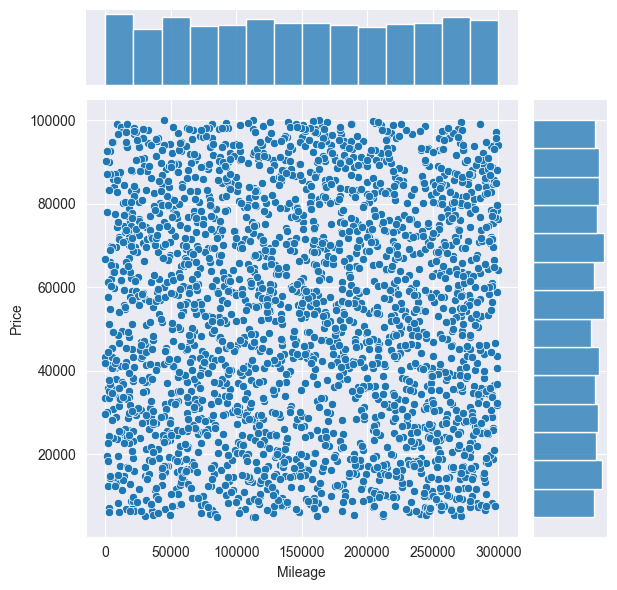

In [96]:
g = sns.JointGrid(data = df , x = 'Mileage' , y = 'Price')
g.plot(sns.scatterplot,
      sns.histplot)

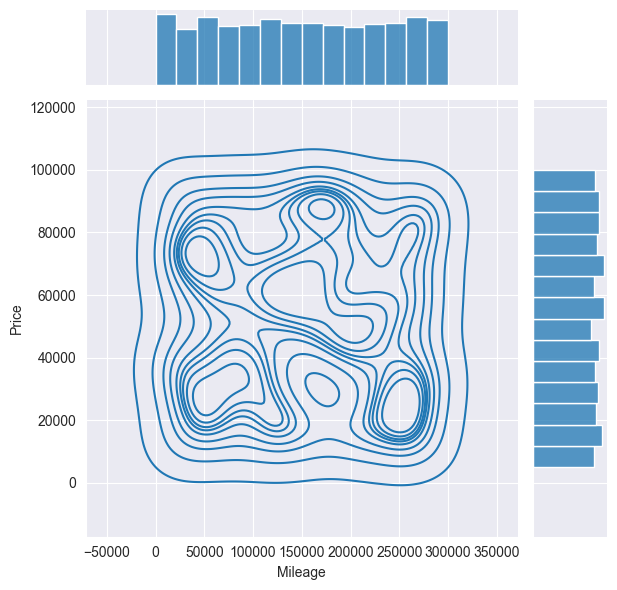

In [98]:
g = sns.JointGrid(data = df , x = 'Mileage' , y = 'Price')
g.plot_joint(sns.kdeplot)
g.plot_marginals(sns.histplot)

In [104]:
!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 5.8 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/11.3 MB 4.7 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.3 MB 5.3 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.3 MB 5.6 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 6.8 MB/s  0:00:01

   ---------------------------------------- 0/6 [wrapt]
   ---------------------------------------- 0/6 [wrapt]
   ---------------------------------------- 0/6 [wrapt]
   ---------------------------------------- 0/6 [wrapt]
   ----------

<Axes: xlabel='Mileage', ylabel='Price'>

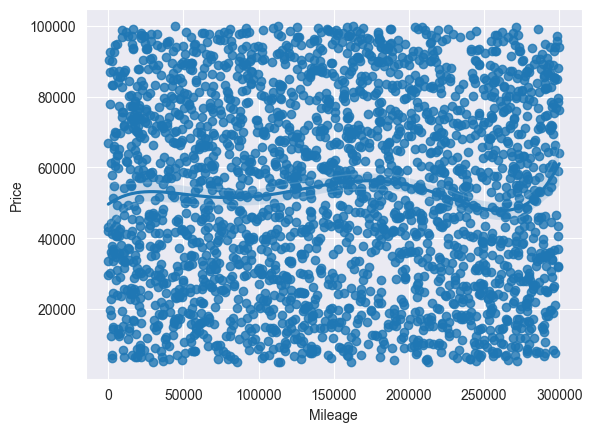

In [110]:
sns.regplot(data = df , x = 'Mileage' , y = 'Price' ,order = 5)

<Axes: xlabel='Price', ylabel='Density'>

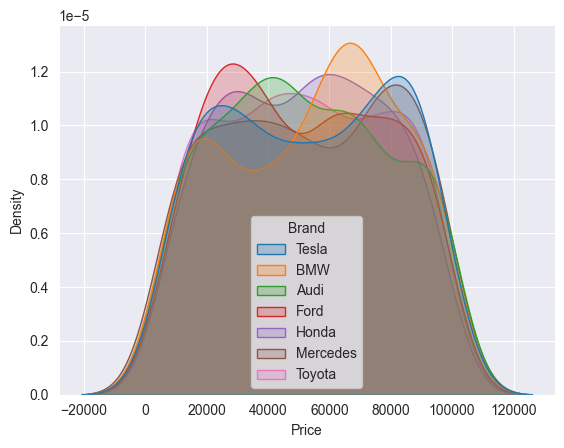

In [111]:
sns.kdeplot(data = df , x = 'Price', hue = "Brand" , fill = True , common_norm = False)

<Axes: xlabel='Brand', ylabel='Price'>

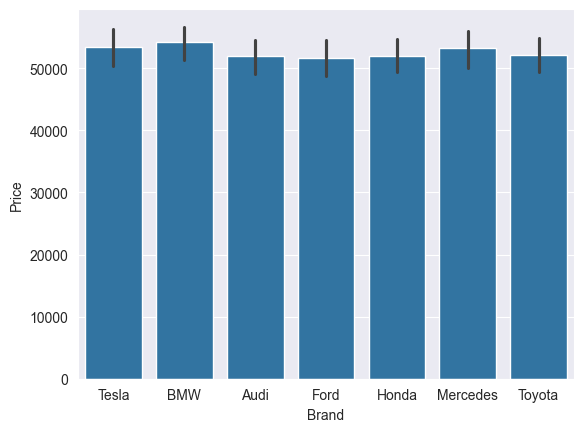

In [115]:
sns.barplot(data = df , x = 'Brand' , y = 'Price')

<Axes: xlabel='Brand', ylabel='Price'>

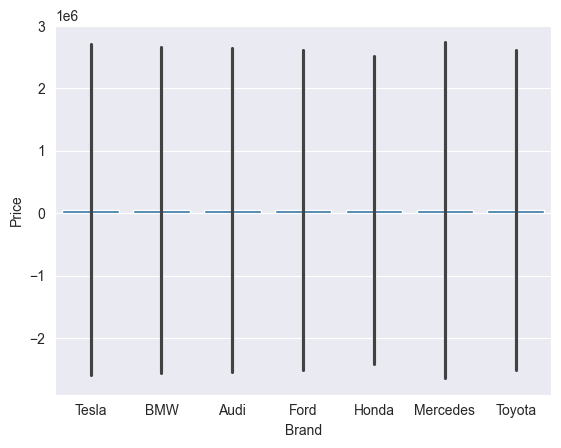

In [116]:
sns.barplot(data = df , x = 'Brand' , y = 'Price'  , errorbar = ('sd',95))

In [31]:
x = df.drop(columns = ['Car ID','Price'])
y = df['Price']
x

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,Mustang
...,...,...,...,...,...,...,...,...
2495,Audi,2020,2.4,Petrol,Automatic,22650,Like New,Q5
2496,Audi,2001,5.7,Hybrid,Manual,77701,Like New,A3
2497,Ford,2021,1.1,Hybrid,Manual,272827,Like New,Fiesta
2498,Audi,2002,4.5,Diesel,Manual,229164,Like New,Q5


In [32]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)
x_train.shape , x_test.shape

((2000, 8), (500, 8))

In [38]:
numeric_cols = x.select_dtypes(include = np.number).columns.tolist()
categorical_cols = x.select_dtypes(include = 'object').columns.tolist()
len(numeric_cols), len(categorical_cols)

(3, 5)

In [39]:
numeric_transform = make_pipeline(
    MinMaxScaler()
)

categorical_transform = make_pipeline(
    OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
)

preprocess = ColumnTransformer(
    transformers = [
        ('num' , numeric_transform , numeric_cols),
        ('cat' , categorical_transform , categorical_cols)
    ]
)

In [59]:
model_and_params = [
    ("LinearRegression",LinearRegression(), {}),
    ("decisiontreeregressor",DecisionTreeRegressor(),{
        'decisiontreeregressor__max_features': [5 , 6 , 7],
        'decisiontreeregressor__max_depth': [10, 5,15]
    }),

    ("RandomForest",RandomForestRegressor(), {
        "randomforestregressor__n_estimators": [100 , 50 , 150],
        "randomforestregressor__max_depth": [10 , 20, 15],
        'randomforestregressor__max_features': [5 , 7, 8],
        "randomforestregressor__max_samples":[1000 , 2000 , 1500]
    } )
]


In [60]:
RMSE = []
model_name = []

for name , model , param_grid in model_and_params:
    pipe = make_pipeline(preprocess , model)
    if param_grid:
        grid = GridSearchCV(pipe ,
                            param_grid = param_grid ,
                            cv = 5 , 
                            scoring = 'neg_root_mean_squared_error',
                           n_jobs = -1)
        grid.fit(x_train , y_train)
        best_model = grid.best_estimator_
        print(f"{name} best parameters {grid.best_params_}")

    else:
        best_model = pipe
        best_model.fit(x_train , y_train)

    preds = best_model.predict(x_train)
    rmse = root_mean_squared_error(y_train , preds)
    RMSE.append(round(rmse , 2))
    model_name.append(name)
    print(f"{name} RMSE: {rmse} ")
    

    

LinearRegression RMSE: 26961.284810224137 
decisiontreeregressor best parameters {'decisiontreeregressor__max_depth': 5, 'decisiontreeregressor__max_features': 7}
decisiontreeregressor RMSE: 26832.78861486843 


C:\Users\tanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
135 fits failed out of a total of 405.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\tanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\tanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\tanu\AppData

RandomForest best parameters {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': 7, 'randomforestregressor__max_samples': 1000, 'randomforestregressor__n_estimators': 150}
RandomForest RMSE: 23859.006676895606 


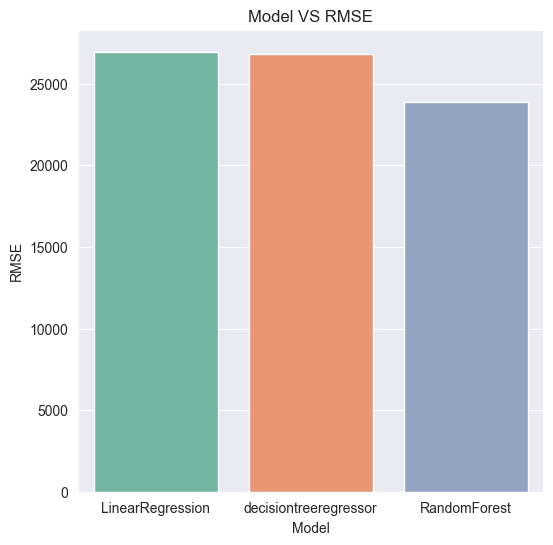

In [118]:
plt.figure(figsize = (6 , 6))
sns.barplot(x = model_name, y = RMSE ,hue = model_name, palette = "Set2")
plt.title("Model VS RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()